In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Configuración e Importación de Librerías

In [20]:
import os
import random
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from tqdm import tqdm
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import NMF
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import MinMaxScaler

# --- CONFIGURACIÓN DE RUTAS ---
DATASET_PATH = "/content/drive/MyDrive/FINAL_DATASET/AUDIO/"
CSV_OUTPUT = "/content/drive/MyDrive/FINAL_DATASET/AUDIO/features_mfcc_nuevo.csv"
MODEL_SAVE_PATH = "/content/drive/MyDrive/FINAL_DATASET/AUDIO/modelo_audiov2.pkl"

##Visualización de MFCC

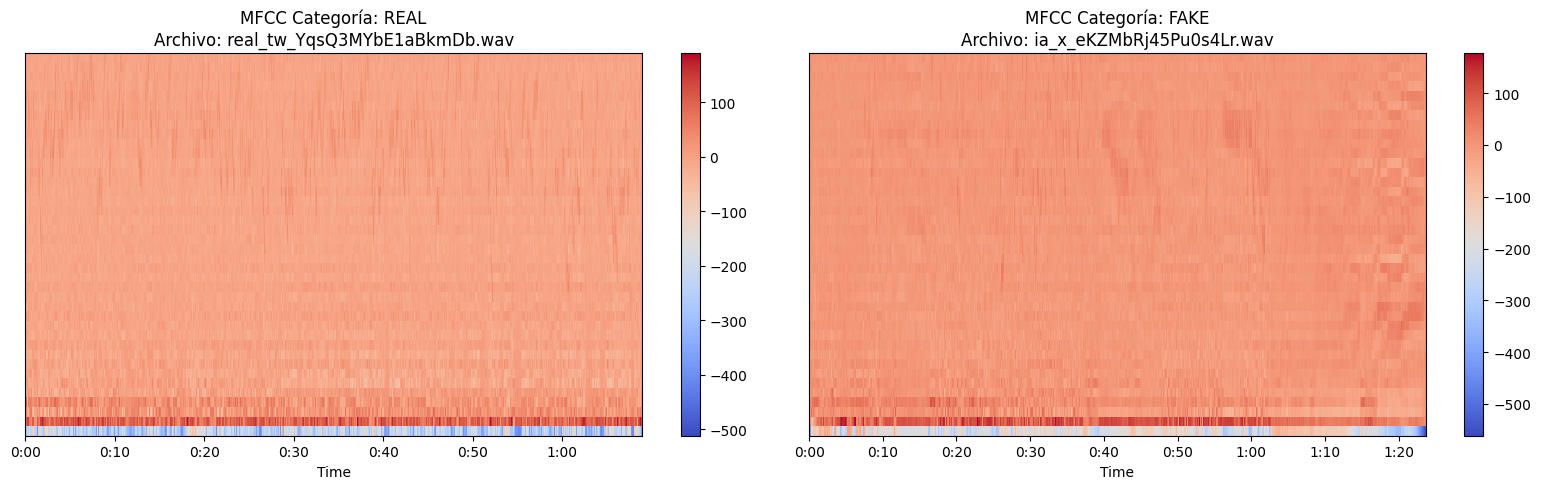

In [21]:
def visualize_comparative_mfcc(base_path):
    categories = ['REAL', 'FAKE']
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for i, category in enumerate(categories):
        folder = os.path.join(base_path, category)

        # Validar que la carpeta no esté vacía
        files = [f for f in os.listdir(folder) if f.endswith(('.wav', '.mp3', '.flac'))]
        if not files:
            print(f"No se encontraron archivos en la carpeta: {folder}")
            continue

        file_name = random.choice(files)
        file_path = os.path.join(folder, file_name)

        # Carga y extracción
        y, sr = librosa.load(file_path, sr=16000)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

        # Graficado en el subplot correspondiente
        img = librosa.display.specshow(mfccs, x_axis='time', sr=sr, ax=axes[i])
        fig.colorbar(img, ax=axes[i])
        axes[i].set_title(f'MFCC Categoría: {category}\nArchivo: {file_name}')

    plt.tight_layout()
    plt.show()

# Ejecutar la visualización
visualize_comparative_mfcc(DATASET_PATH)

##Extrar caracteristicas

In [22]:
def extract_and_save_features(base_path, output_csv):
    data = []
    labels = []
    file_paths = []

    # 1. Extracción inicial de MFCC
    for label_name in ['REAL', 'FAKE']:
        folder = os.path.join(base_path, label_name)
        label = 0 if label_name == 'REAL' else 1
        for file in tqdm(os.listdir(folder), desc=f"Extrayendo MFCC {label_name}"):
            path = os.path.join(folder, file)
            try:
                y, sr = librosa.load(path, sr=16000)
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
                mfcc_mean = np.mean(mfcc.T, axis=0)
                data.append(mfcc_mean)
                labels.append(label)
                file_paths.append(file)
            except Exception as e:
                continue

    X_mfcc = np.array(data)
    y = np.array(labels)

    # 2. Transformación MFCC-GNB
    gnb = GaussianNB()
    gnb.fit(X_mfcc, y)
    X_prob = gnb.predict_proba(X_mfcc)

    # 3. Refinamiento NMF
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_mfcc)

    nmf = NMF(n_components=20, init='random', random_state=42, max_iter=500)
    X_nmf = nmf.fit_transform(X_scaled)

    X_final = np.hstack((X_prob, X_nmf))

    df = pd.DataFrame(X_final)
    df['label'] = y
    df['file_name'] = file_paths
    df.to_csv(output_csv, index=False)

    print(f"Dataset guardado en {output_csv}")

    # --- CAMBIO IMPORTANTE: Retornamos los objetos ---
    return gnb, scaler, nmf

# Ejecutamos y capturamos los objetos en variables globales
gnb, scaler, nmf = extract_and_save_features(DATASET_PATH, CSV_OUTPUT)

Extrayendo MFCC FAKE: 100%|██████████| 202/202 [00:35<00:00,  5.74it/s]
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Dataset guardado en /content/drive/MyDrive/FINAL_DATASET/AUDIO/features_mfcc_nuevo.csv


##Entrenamiento de RF y Validación Cruzada

========== INFORMACIÓN DEL DATASET ==========
Total de muestras: 387
Número de características: 22

Distribución de clases:
label
1    202
0    185
Name: count, dtype: int64

Distribución porcentual:
label
1    52.196382
0    47.803618
Name: proportion, dtype: float64

========== DIVISIÓN DE DATOS ==========
Train + Validation: 309 muestras
Test: 78 muestras

             VALIDACIÓN CRUZADA 10-FOLD

----- FOLD 1 -----
Entrenamiento: 278 muestras
Validación:    31 muestras
Accuracy:  0.6774
Precision: 0.6500
Recall:    0.8125
F1-Score:  0.7222

Matriz de confusión:
[[ 8  7]
 [ 3 13]]

----- FOLD 2 -----
Entrenamiento: 278 muestras
Validación:    31 muestras
Accuracy:  0.5806
Precision: 0.5714
Recall:    0.7500
F1-Score:  0.6486

Matriz de confusión:
[[ 6  9]
 [ 4 12]]

----- FOLD 3 -----
Entrenamiento: 278 muestras
Validación:    31 muestras
Accuracy:  0.7097
Precision: 0.7059
Recall:    0.7500
F1-Score:  0.7273

Matriz de confusión:
[[10  5]
 [ 4 12]]

----- FOLD 4 -----
Entrenamiento:

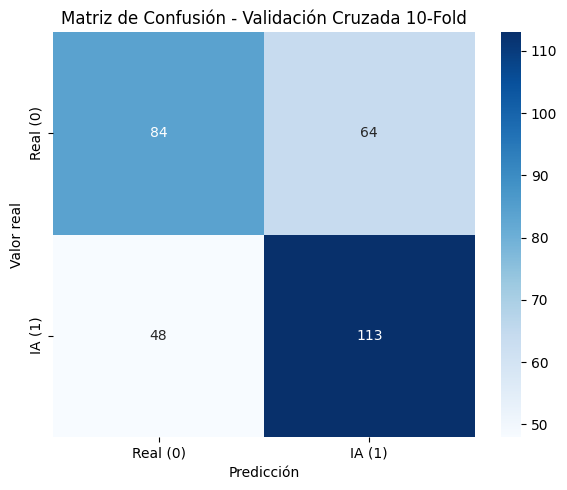


             ENTRENAMIENTO DEL MODELO FINAL

             MÉTRICAS - CONJUNTO DE TEST
Accuracy:  0.7308
Precision: 0.7273
Recall:    0.7805
F1-Score:  0.7529

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.74      0.68      0.70        37
      IA (1)       0.73      0.78      0.75        41

    accuracy                           0.73        78
   macro avg       0.73      0.73      0.73        78
weighted avg       0.73      0.73      0.73        78


              MATRIZ DE CONFUSIÓN - TEST
[[25 12]
 [ 9 32]]


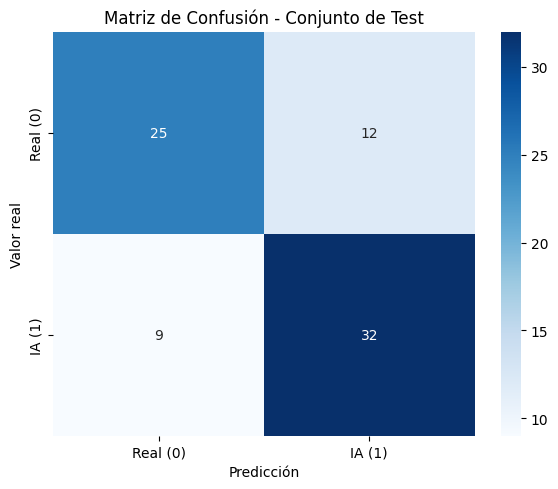


             DATOS DE TEST Y PREDICCIONES
                                                                                                                                               file_name  Real  Predicción  Resultado
                                                                                                           ia_ssstik.io_@confesor.pari_1787029316832.wav     1           1   Correcto
                                                                           real_Aldo-Bravo-hoy-tenemos-a-todos-contra-Ra_Media_KkIfJQCyA5A_001_1080p.wav     0           0   Correcto
                                                                                                   no_ia_tk_@peruprimero_oficial_7559331868600995090.wav     0           0   Correcto
                                                                                                          ia_ssstik.io_@niltoncaurino0_1787026575552.wav     1           1   Correcto
                                               

In [23]:
# ============================================================
# RANDOM FOREST - VALIDACIÓN 10-FOLD + TEST
# Métricas, matrices y datos de validación
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. CARGAR DATOS
# ============================================================

df_data = pd.read_csv(CSV_OUTPUT)

# Separar variables predictoras y etiqueta
X = df_data.drop(['label', 'file_name'], axis=1)
y = df_data['label']

print("========== INFORMACIÓN DEL DATASET ==========")
print(f"Total de muestras: {len(df_data)}")
print(f"Número de características: {X.shape[1]}")
print("\nDistribución de clases:")
print(y.value_counts())
print("\nDistribución porcentual:")
print(y.value_counts(normalize=True) * 100)


# ============================================================
# 2. DIVISIÓN TRAIN/TEST
# ============================================================

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n========== DIVISIÓN DE DATOS ==========")
print(f"Train + Validation: {len(X_train_val)} muestras")
print(f"Test: {len(X_test)} muestras")


# ============================================================
# 3. DEFINIR RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    criterion='gini',
    max_leaf_nodes=31,
    random_state=42
)


# ============================================================
# 4. VALIDACIÓN CRUZADA 10-FOLD
# ============================================================

kf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Listas para guardar resultados
fold_results = []

# Guardar predicciones y valores reales de cada fold
all_y_true = []
all_y_pred = []

print("\n============================================================")
print("             VALIDACIÓN CRUZADA 10-FOLD")
print("============================================================")

for fold, (train_idx, val_idx) in enumerate(
    kf.split(X_train_val, y_train_val), 1
):

    # --------------------------------------------------------
    # Datos de entrenamiento y validación del fold
    # --------------------------------------------------------

    X_fold_train = X_train_val.iloc[train_idx]
    X_fold_val = X_train_val.iloc[val_idx]

    y_fold_train = y_train_val.iloc[train_idx]
    y_fold_val = y_train_val.iloc[val_idx]

    # --------------------------------------------------------
    # Crear un modelo independiente para cada fold
    # --------------------------------------------------------

    fold_model = RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        criterion='gini',
        max_leaf_nodes=31,
        random_state=42
    )

    # Entrenar
    fold_model.fit(X_fold_train, y_fold_train)

    # Predecir validación
    y_fold_pred = fold_model.predict(X_fold_val)

    # --------------------------------------------------------
    # Calcular métricas
    # --------------------------------------------------------

    accuracy = accuracy_score(y_fold_val, y_fold_pred)

    precision = precision_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    # Matriz de confusión
    cm = confusion_matrix(y_fold_val, y_fold_pred)

    # Guardar resultados
    fold_results.append({
        'Fold': fold,
        'Train Samples': len(X_fold_train),
        'Validation Samples': len(X_fold_val),
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    # Guardar predicciones
    all_y_true.extend(y_fold_val)
    all_y_pred.extend(y_fold_pred)

    # --------------------------------------------------------
    # Mostrar resultados del fold
    # --------------------------------------------------------

    print(f"\n----- FOLD {fold} -----")
    print(f"Entrenamiento: {len(X_fold_train)} muestras")
    print(f"Validación:    {len(X_fold_val)} muestras")

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    print("\nMatriz de confusión:")
    print(cm)


# ============================================================
# 5. TABLA DE RESULTADOS DE CADA FOLD
# ============================================================

df_cv_results = pd.DataFrame(fold_results)

print("\n\n============================================================")
print("              RESULTADOS POR FOLD")
print("============================================================")

print(df_cv_results.to_string(index=False))


# ============================================================
# 6. PROMEDIO Y DESVIACIÓN ESTÁNDAR
# ============================================================

metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

print("\n============================================================")
print("             MÉTRICAS PROMEDIO 10-FOLD")
print("============================================================")

for metric in metrics:

    mean_value = df_cv_results[metric].mean()
    std_value = df_cv_results[metric].std()

    print(
        f"{metric}: "
        f"{mean_value:.4f} ± {std_value:.4f}"
    )


# ============================================================
# 7. MATRIZ DE CONFUSIÓN GLOBAL DE VALIDACIÓN
# ============================================================

cm_cv = confusion_matrix(
    all_y_true,
    all_y_pred
)

print("\n============================================================")
print("          MATRIZ DE CONFUSIÓN - VALIDACIÓN")
print("============================================================")

print(cm_cv)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_cv,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Real (0)', 'IA (1)'],
    yticklabels=['Real (0)', 'IA (1)']
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Validación Cruzada 10-Fold')
plt.tight_layout()
plt.show()


# ============================================================
# 8. ENTRENAMIENTO FINAL
# ============================================================

print("\n============================================================")
print("             ENTRENAMIENTO DEL MODELO FINAL")
print("============================================================")

rf_model.fit(
    X_train_val,
    y_train_val
)


# ============================================================
# 9. PREDICCIONES SOBRE TEST
# ============================================================

y_pred = rf_model.predict(X_test)


# ============================================================
# 10. MÉTRICAS DEL CONJUNTO DE TEST
# ============================================================

accuracy_test = accuracy_score(
    y_test,
    y_pred
)

precision_test = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall_test = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1_test = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\n============================================================")
print("             MÉTRICAS - CONJUNTO DE TEST")
print("============================================================")

print(f"Accuracy:  {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall:    {recall_test:.4f}")
print(f"F1-Score:  {f1_test:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Real (0)', 'IA (1)'],
        zero_division=0
    )
)


# ============================================================
# 11. MATRIZ DE CONFUSIÓN DEL TEST
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_pred
)

print("\n============================================================")
print("              MATRIZ DE CONFUSIÓN - TEST")
print("============================================================")

print(cm_test)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Real (0)', 'IA (1)'],
    yticklabels=['Real (0)', 'IA (1)']
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Conjunto de Test')
plt.tight_layout()
plt.show()


# ============================================================
# 12. DATOS DE TEST CON PREDICCIONES
# ============================================================

df_test_results = X_test.copy()

# Recuperar nombres de archivo
df_test_results['file_name'] = df_data.loc[
    X_test.index,
    'file_name'
]

# Valor real y predicción
df_test_results['Real'] = y_test
df_test_results['Predicción'] = y_pred

# Indicar si acertó o no
df_test_results['Resultado'] = np.where(
    y_test.values == y_pred,
    'Correcto',
    'Incorrecto'
)

print("\n============================================================")
print("             DATOS DE TEST Y PREDICCIONES")
print("============================================================")

print(
    df_test_results[
        ['file_name', 'Real', 'Predicción', 'Resultado']
    ].to_string(index=False)
)


# ============================================================
# 13. GUARDAR RESULTADOS EN CSV
# ============================================================

df_cv_results.to_csv(
    'resultados_validacion_10fold.csv',
    index=False
)

df_test_results.to_csv(
    'resultados_test_random_forest.csv',
    index=False
)

print("\n============================================================")
print("Archivos generados:")
print(" - resultados_validacion_10fold.csv")
print(" - resultados_test_random_forest.csv")
print("============================================================")

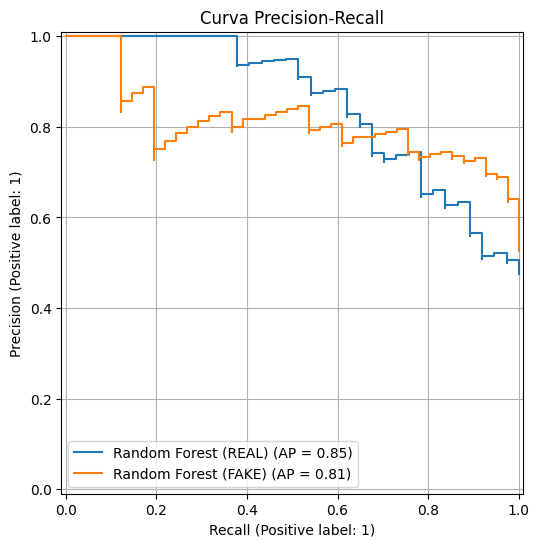

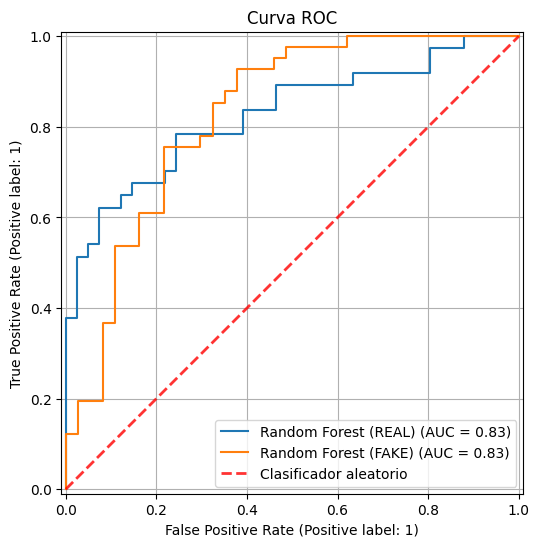

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# Curva Precision-Recall para ambas categorías
fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
for i, class_name in enumerate(['REAL', 'FAKE']):
    PrecisionRecallDisplay.from_estimator(rf_model, X_test, y_test, ax=ax_pr, name=f'Random Forest ({class_name})', pos_label=i)
ax_pr.set_title('Curva Precision-Recall')
plt.grid(True)
plt.legend()
plt.show()

# Curva ROC para ambas categorías
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
for i, class_name in enumerate(['REAL', 'FAKE']):
    RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax_roc, name=f'Random Forest ({class_name})', pos_label=i)
ax_roc.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Clasificador aleatorio', alpha=.8)
ax_roc.set_title('Curva ROC')
plt.grid(True)
plt.legend()
plt.show()

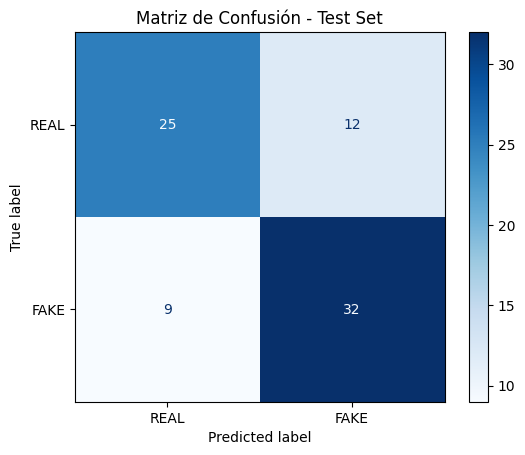

In [25]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['REAL', 'FAKE'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Test Set")
plt.show()

# Guardar el pipeline
components = {
    'rf_model': rf_model,
    'gnb_model': gnb,
    'scaler': scaler,
    'nmf_model': nmf
}

In [28]:
joblib.dump(components, MODEL_SAVE_PATH)

print(f"Pipeline guardado exitosamente en: {MODEL_SAVE_PATH}")

Modelo guardado exitosamente en: /content/drive/MyDrive/FINAL_DATASET/random_forest_model.pkl
